# **Overfitting & Underfitting Decision Trees**

## Setting Up the Environment and Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

## Visualizing Decision Tree Boundaries

## Visualizing Decision Tree Boundaries

The `analyzer` function is designed to visualize how different maximum depths (`max_depth`) in a Decision Tree Classifier affect the model's decision boundaries on a given dataset. Here's a detailed breakdown of the function:

### Function Definition
- `def analyzer(max_depth)`: This function, named `analyzer`, takes a single parameter `max_depth`, which allows us to control the complexity of the decision tree model.

### Data Loading and Preparation
- `data = pd.read_csv("Social_Network_Ads.csv")`: The dataset `Social_Network_Ads.csv`, presumably containing social network advertisement data, is loaded using Pandas.
- `X = data.iloc[:,2:4].values`: The features for the model are extracted, specifically the third and fourth columns of the dataset.
- `y = data.iloc[:,-1].values`: The target variable is obtained from the last column of the dataset, indicating the labels or classes.

### Model Training
- `clf = DecisionTreeClassifier(max_depth=max_depth)`: A Decision Tree Classifier is instantiated with the specified `max_depth`.
- `clf.fit(X, y)`: The classifier is trained using the features `X` and the target `y`.

### Decision Boundary Visualization
- The function then creates a mesh grid for plotting the decision boundaries:
   - Ranges `a` and `b` are defined based on the minimum and maximum values of the features, with a buffer.
   - `XX, YY = np.meshgrid(a, b)`: A mesh grid is generated for visualization purposes.
   - `input_array = np.array([XX.ravel(), YY.ravel()]).T`: This array represents all the points in the grid.
   - `labels = clf.predict(input_array)`: The classifier predicts the class for each point in the grid.
- `plt.contourf(XX, YY, labels.reshape(XX.shape), alpha=0.5)`: The decision boundary is visualized using a contour plot.
- `plt.scatter(X[:,0], X[:,1], c=y)`: The original data points are plotted, with colors indicating their actual class.

### Usage and Expected Observations
- By executing this function with different `max_depth` values, we can observe the impact of tree depth on model complexity and generalization.
- A shallow tree (`small max_depth`) might show a too simplistic boundary (underfitting), while a deep tree (`large max_depth`) could create overly complex boundaries (overfitting).
- An optimal `max_depth` should find a balance, creating boundaries that accurately classify most of the points without being overly complex.

This visualization is crucial for understanding how decision tree models partition the feature space and make predictions, providing insights into the trade-offs between underfitting and overfitting in machine learning.

In [2]:
def analyzer(max_depth):
    data = pd.read_csv("/kaggle/input/social-network-ads/Social_Network_Ads.csv")
    X = data.iloc[:,0:2].values
    y = data.iloc[:,-1].values

    clf = DecisionTreeClassifier(max_depth=max_depth)
    clf.fit(X,y)

    a = np.arange(start = X[:,0].min()-1, stop = X[:,0].max()+1, step=0.1)
    b = np.arange(start= X[:,1].min()-1, stop= X[:,1].max()+1, step = 100)
    XX, YY = np.meshgrid(a,b)
    input_array = np.array([XX.ravel(), YY.ravel()]).T
    labels = clf.predict(input_array)
    plt.contourf(XX, YY, labels.reshape(XX.shape), alpha=0.5)
    plt.scatter(X[:,0], X[:,1],c=y)

### Decision Tree Classifier with `max_depth=None`

In this visualization, we observe the decision boundary of a Decision Tree Classifier that has been trained without any restriction on its depth (`max_depth=None`). This setup allows the tree to create very specific rules to classify every point in the training set accurately.

#### Observations:
- The decision boundary is highly complex and non-linear, indicating that the classifier is attempting to capture every nuance in the training data.
- Such a complex model is prone to overfitting, as it may not only learn the signal but also the noise within the training data. This is evident from the very intricate patterns in the decision regions, which do not generalize well.
- The model's overfitting is further suggested by the existence of decision regions in areas devoid of data points, meaning the model predicts certain classes where there is no evidence from the training data.
- A more generalized model might be achieved by restricting the tree's growth with a `max_depth` parameter set to a suitable value, thus preventing it from becoming too complex.

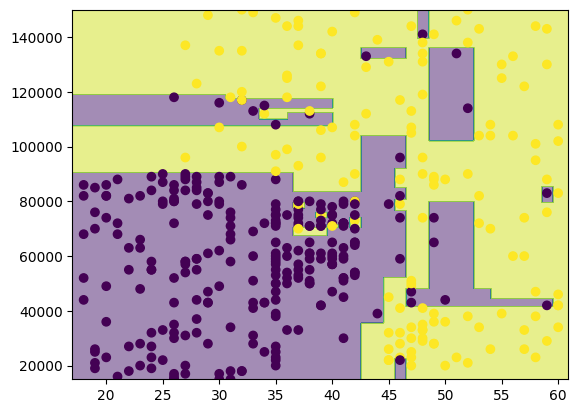

In [3]:
analyzer(max_depth=None)

### Decision Tree Classifier with `max_depth=1`

In this visualization, we examine the decision boundary of a Decision Tree Classifier that has been trained with a maximum depth of 1.

#### Observations:
- The boundary is a simple, straight line, reflecting the decision tree's limited capacity to make just one decision based on the input features.
- This simplistic approach to decision-making is a classic sign of underfitting, where the model fails to capture the complexity of the underlying data structure.
- Many data points that belong to one class are found on the wrong side of the decision boundary, suggesting that the model's rules are too broad and not nuanced enough.
- While such a model is unlikely to overfit and may have good generalization in terms of simplicity, it might not perform well in practice due to its poor fit to the training data.

This kind of model might benefit from increasing the `max_depth` parameter to allow for more complex decision-making that can capture more detailed patterns in the data.

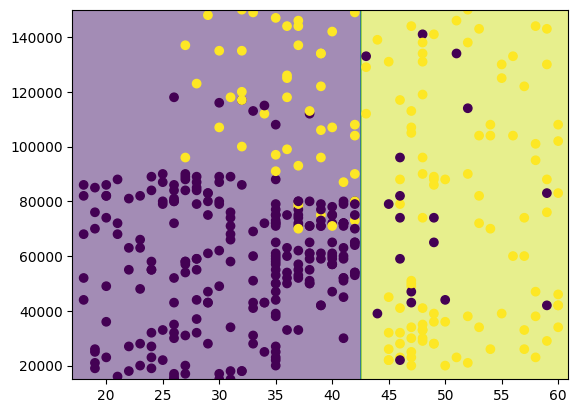

In [4]:
analyzer(max_depth=1)

### Decision Tree Classifier with `max_depth=5`

This visualization depicts the decision boundary of a Decision Tree Classifier trained with a maximum depth of 5.

#### Observations:
- The boundary shows a moderate level of complexity, suggesting that the classifier is now taking into account more information about the data, which is reflected in the number and shape of the decision regions.
- There is a visible attempt to balance the model's complexity, reducing the risk of overfitting while still trying to capture the patterns necessary for accurate classification.
- Some data points are still misclassified, as evidenced by points that lie in regions not corresponding to their class. However, this is an expected trade-off when trying to maintain a model that generalizes well.
- A `max_depth` of 5 can often be a good starting point for further tuning, as it provides a model that neither oversimplifies nor overcomplicates the task at hand.

This model's performance can be a baseline for comparison when you experiment with different values of `max_depth` to find the optimal balance for your specific dataset.


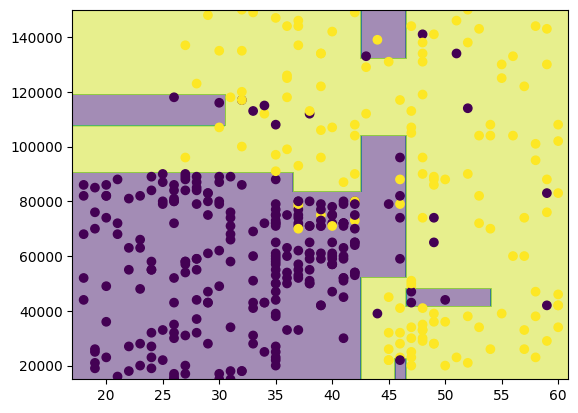

In [5]:
analyzer(max_depth=5)

### Decision Tree Classifier with `max_depth=3`

This visualization shows the decision boundary of a Decision Tree Classifier with a maximum depth set to 3.

#### Observations:
- The decision boundary has a moderate level of complexity, indicating that the model is making a series of decisions to classify the data, which could lead to better performance than the simplest model.
- The model with `max_depth=3` is an example of attempting to find a middle ground in model complexity, reducing the likelihood of overfitting while still capturing sufficient detail for accurate classification.
- The decision regions are more nuanced than in the `max_depth=1` model, suggesting a better understanding of the data's structure without going to the extremes of fitting to the noise, as in the unrestricted case.
- Overall, this model may represent a good compromise, offering a reasonable approximation of the underlying data distribution while maintaining the ability to generalize to new data.

The performance of this model can be a good indicator of whether a more complex or simpler model is necessary. Further experimentation with `max_depth` and other hyperparameters would help in fine-tuning the model to achieve the best possible performance on this dataset.

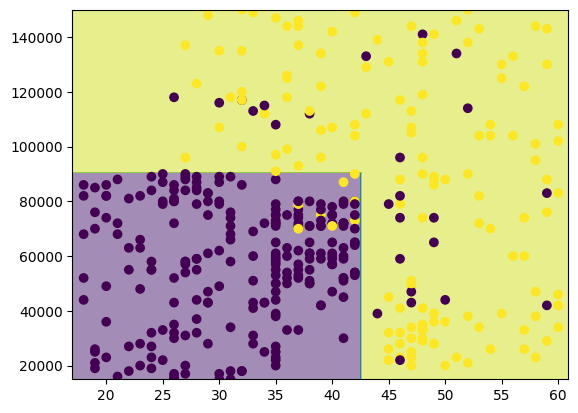

In [6]:
analyzer(max_depth=3)